In [7]:
import yaml
import pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [8]:
# Open data folder
DATA_DIR = Path.cwd().parent.parent / "data"

# Build Path 
intents_path = DATA_DIR / "intents.yaml"
responses_path = DATA_DIR / "responses.yaml"

# Load Data
intents = yaml.safe_load(intents_path.read_text())
# responses = yaml.safe_load(responses_path.read_text())

X = []
Y = []
# fill X and Y
for (key, text_list) in intents["intents"].items():
    for text in text_list:
        X.append(text)
        Y.append(key)

In [9]:
# Vectorizer
#v = TfidfVectorizer()
#transformed_output = v.fit_transform(X)
#print(transformed_output.shape)

In [10]:
# Train test
X_train, X_test,  Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=20, stratify=Y)

In [11]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(class_weight="balanced", C=1.0, max_iter=1000)),
])

In [13]:
pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


               precision    recall  f1-score   support

    about_him       0.60      0.75      0.67         4
   ai_journey       1.00      0.50      0.67         4
      contact       0.50      0.60      0.55         5
current_focus       1.00      1.00      1.00         4
      goodbye       1.00      1.00      1.00         3
        greet       0.62      1.00      0.77         5
 out_of_scope       1.00      0.38      0.55         8
     projects       0.75      1.00      0.86         3
  skills_tech       0.60      0.75      0.67         4
       thanks       1.00      1.00      1.00         4

     accuracy                           0.75        44
    macro avg       0.81      0.80      0.77        44
 weighted avg       0.81      0.75      0.74        44



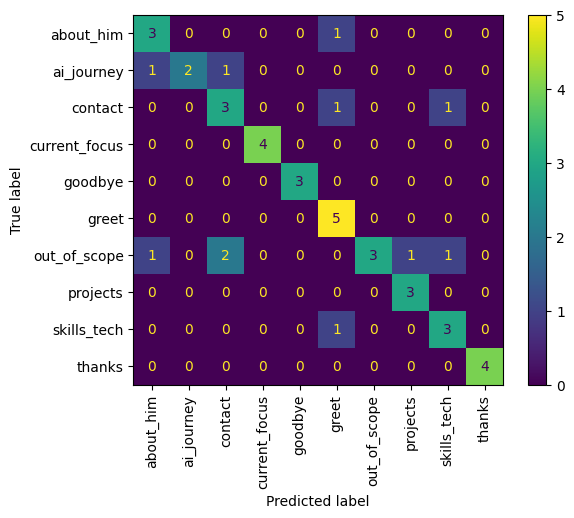

In [28]:
y_pred = pipeline.predict(X_test)
print(classification_report(Y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(Y_test, y_pred, xticks_rotation="vertical")